In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataCoSupplyChainDataset.csv/DataCoSupplyChainDataset.csv", encoding="latin1")

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,180519,4,DEBIT,69295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days for shipping (real),180519.0,NaN,NaN,NaN,3.497654,1.623722,0.0,2.0,3.0,5.0,6.0
Days for shipment (scheduled),180519.0,NaN,NaN,NaN,2.931847,1.374449,0.0,2.0,4.0,4.0,4.0
Benefit per order,180519.0,NaN,NaN,NaN,21.974989,104.433526,-4274.97998,7.0,31.52,64.800003,911.799988
Sales per customer,180519.0,NaN,NaN,NaN,183.107609,120.04367,7.49,104.379997,163.990005,247.399994,1939.98999
Delivery Status,180519,4,Late delivery,98977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
Category Id,180519.0,NaN,NaN,NaN,31.851451,15.640064,2.0,18.0,29.0,45.0,76.0
Category Name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer City,180519,563,Caguas,66770,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
drop_cols = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Image",
    "Product Description"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [ ]:
df["order_date"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping_date"] = pd.to_datetime(df["shipping date (DateOrders)"])

df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_dayofweek"] = df["order_date"].dt.dayofweek
df["order_week"] = df["order_date"].dt.isocalendar().week.astype(int)
df["order_hour"] = df["order_date"].dt.hour

In [ ]:
df["shipping_delay"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

df["profit_margin"] = df["Order Profit Per Order"] / df["Sales"]
df["profit_margin"] = df["profit_margin"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["discount_amount_per_unit"] = df["Order Item Discount"] / df["Order Item Quantity"]
df["discount_amount_per_unit"] = df["discount_amount_per_unit"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["is_profitable"] = np.where(df["Order Profit Per Order"] > 0, 1, 0)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,order_year,order_month,order_day,order_dayofweek,order_week,order_hour,shipping_delay,profit_margin,discount_amount_per_unit,is_profitable
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,2018,1,31,2,5,22,-1,0.278413,13.110000,1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,2018,1,13,5,2,12,1,-0.760000,16.389999,0
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,2018,1,13,5,2,12,0,-0.756003,18.030001,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,2018,1,13,5,2,11,-1,0.069748,22.940001,1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,2018,1,13,5,2,11,-2,0.409489,29.500000,1


# Exploratory Data Analysis

In [ ]:
monthly_sales = df.groupby(pd.Grouper(key="order_date", freq="M"))["Sales"].sum().reset_index()

fig = px.line(
    monthly_sales,
    x="order_date",
    y="Sales",
    title="Monthly Sales Trend"
)
fig.show()

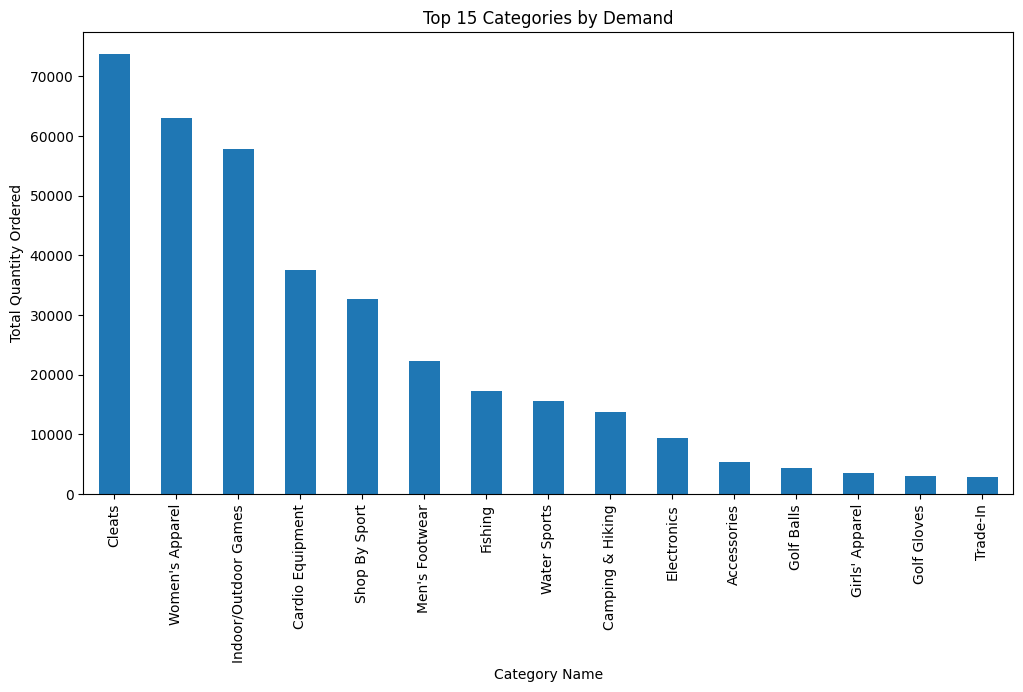

In [ ]:
category_demand = df.groupby("Category Name")["Order Item Quantity"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
category_demand.plot(kind="bar")
plt.title("Top 15 Categories by Demand")
plt.ylabel("Total Quantity Ordered")
plt.xticks(rotation=90)
plt.show()

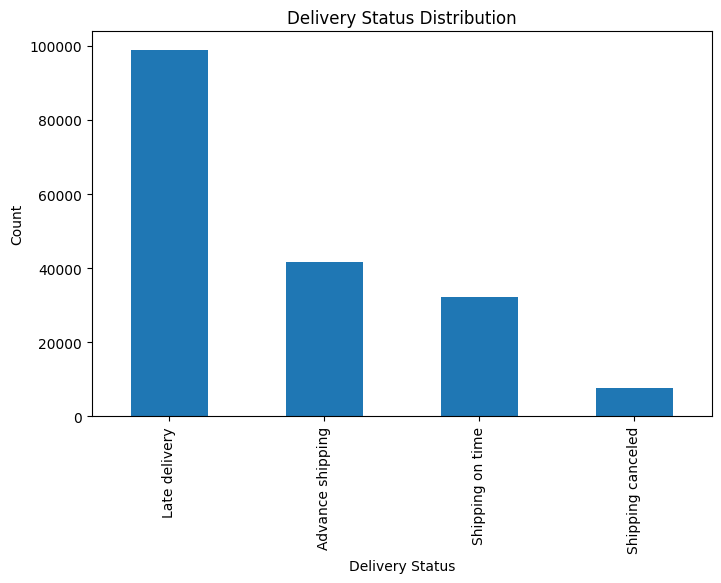

In [ ]:
df["Delivery Status"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Delivery Status Distribution")
plt.ylabel("Count")
plt.show()

In [ ]:
market_sales = df.groupby("Market")["Sales"].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    market_sales,
    x="Market",
    y="Sales",
    title="Sales by Market"
)
fig.show()

In [ ]:
region_profit = df.groupby("Order Region")["Order Profit Per Order"].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    region_profit,
    x="Order Region",
    y="Order Profit Per Order",
    title="Profit by Region"
)
fig.show()

In [ ]:
# Late delivery rate by shipping mode
mode_late = (df.groupby("Shipping Mode")["Late_delivery_risk"]
               .mean().mul(100).reset_index()
               .rename(columns={"Late_delivery_risk": "Late Delivery Rate (%)"}))

fig = px.bar(mode_late, x="Shipping Mode", y="Late Delivery Rate (%)",
             title="Late Delivery Rate by Shipping Mode")
fig.show()

# Feature Engineering

In [ ]:
ml_df = df.copy()

features_common = [
    "Type",
    "Days for shipment (scheduled)",
    "Sales per customer",
    "Category Name",
    "Customer Segment",
    "Market",
    "Order Region",
    "Order Country",
    "Order State",
    "Shipping Mode",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Product Price",
    "Order Item Quantity",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order",
    "order_month",
    "order_dayofweek",
    "order_hour",
    "profit_margin",
    "discount_amount_per_unit"
]

ml_df = ml_df[features_common + ["Late_delivery_risk"]].dropna()

# Late Delivery Risk Classifier

In [ ]:
# Features we know AT THE TIME of the order — before any shipping happens
features_clf = [
    "Type",                          # payment type chosen by customer
    "Days for shipment (scheduled)", # how many days were promised
    "Sales per customer",            # customer's historical spend
    "Category Name",                 # product category
    "Customer Segment",              # consumer, corporate, home office
    "Market",                        # geographic market
    "Order Region",                  # region of the order
    "Shipping Mode",                 # shipping method chosen
    "Order Item Discount Rate",      # discount applied
    "Order Item Product Price",      # price of the item
    "Order Item Quantity",           # how many units ordered
    "order_month",                   # month the order was placed
    "order_dayofweek",               # day of the week
    "order_hour",                    # hour of the day
    "Department Name",               # department the product belongs to
]

clf_df = df[features_clf + ["Late_delivery_risk"]].dropna()

X_clf = clf_df[features_clf]
y_clf = clf_df["Late_delivery_risk"]

print(f"Total rows: {len(X_clf):,}")
print(f"On-time orders (0): {(y_clf == 0).sum():,}")
print(f"Late orders   (1): {(y_clf == 1).sum():,}")


Total rows: 180,519
On-time orders (0): 81,542
Late orders   (1): 98,977


In [ ]:
# Split the data: 80% for training, 20% for testing
# stratify=y makes sure both splits have the same ratio of late/on-time orders
from sklearn.model_selection import train_test_split

categorical_cols = X_clf.select_dtypes(include="object").columns.tolist()
numeric_cols     = X_clf.select_dtypes(exclude="object").columns.tolist()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Training set: {len(X_train_clf):,} rows")
print(f"Test set:     {len(X_test_clf):,} rows")


Training set: 144,415 rows
Test set:     36,104 rows


In [ ]:
# Preprocessing pipeline
# - StandardScaler: scales numeric columns so large numbers don't dominate
# - OneHotEncoder: converts text categories into numbers the model can read

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor_clf = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])


# Model 1: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_clf),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight="balanced",  # helps because we have slightly more late than on-time
        random_state=42
    ))
])

rf_clf.fit(X_train_clf, y_train_clf)

y_pred_rf  = rf_clf.predict(X_test_clf)
y_proba_rf = rf_clf.predict_proba(X_test_clf)[:, 1]

print("=== Random Forest — Classification Report ===")
print(classification_report(y_test_clf, y_pred_rf, target_names=["On-Time", "Late"]))
print(f"ROC AUC Score: {roc_auc_score(y_test_clf, y_proba_rf):.4f}")


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

     On-Time       0.64      0.88      0.74     16308
        Late       0.86      0.59      0.70     19796

    accuracy                           0.72     36104
   macro avg       0.75      0.73      0.72     36104
weighted avg       0.76      0.72      0.72     36104

ROC AUC Score: 0.7858


# Model 2: XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_clf),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train_clf == 0).sum() / (y_train_clf == 1).sum(),
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_clf.fit(X_train_clf, y_train_clf)

y_pred_xgb  = xgb_clf.predict(X_test_clf)
y_proba_xgb = xgb_clf.predict_proba(X_test_clf)[:, 1]

print("=== XGBoost — Classification Report ===")
print(classification_report(y_test_clf, y_pred_xgb, target_names=["On-Time", "Late"]))
print(f"ROC AUC Score: {roc_auc_score(y_test_clf, y_proba_xgb):.4f}")


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

     On-Time       0.64      0.88      0.74     16308
        Late       0.86      0.59      0.70     19796

    accuracy                           0.72     36104
   macro avg       0.75      0.73      0.72     36104
weighted avg       0.76      0.72      0.72     36104

ROC AUC Score: 0.7890


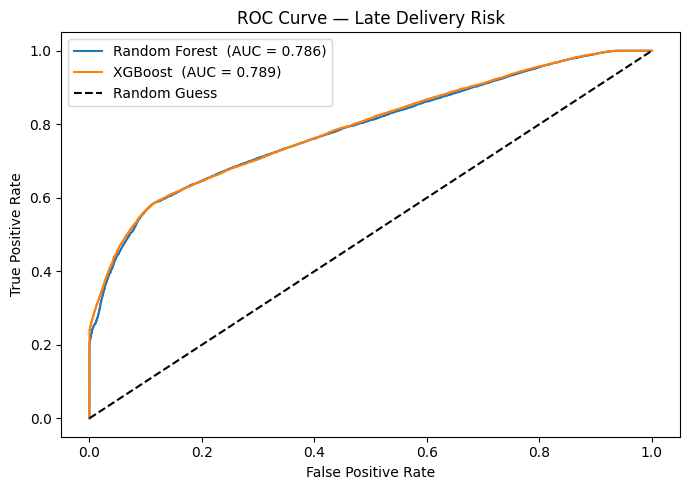

In [ ]:
from sklearn.metrics import roc_curve

# ROC Curve — the closer the curve hugs the top-left corner, the better the model
plt.figure(figsize=(7, 5))

for y_p, label in [(y_proba_rf, "Random Forest"), (y_proba_xgb, "XGBoost")]:
    fpr, tpr, _ = roc_curve(y_test_clf, y_p)
    auc = roc_auc_score(y_test_clf, y_p)
    plt.plot(fpr, tpr, label=f"{label}  (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Late Delivery Risk")
plt.legend()
plt.tight_layout()
plt.show()


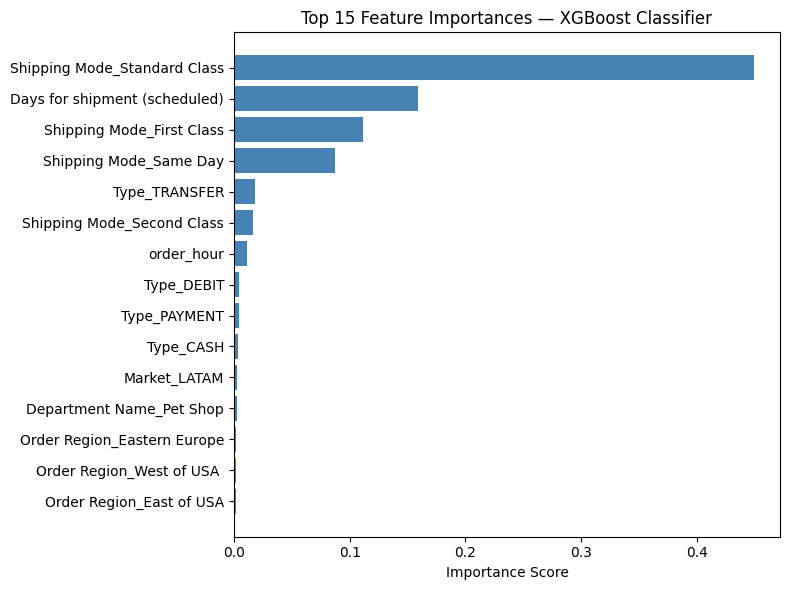

In [ ]:
# Feature Importance — which features matter most to XGBoost?
import numpy as np

# Get feature names after encoding
ohe_feature_names = (xgb_clf.named_steps["preprocessor"]
                     .named_transformers_["cat"]
                     .get_feature_names_out(categorical_cols).tolist())
all_feature_names = numeric_cols + ohe_feature_names

importances = xgb_clf.named_steps["model"].feature_importances_

# Show top 15 features
top_idx = np.argsort(importances)[-15:]
plt.figure(figsize=(8, 6))
plt.barh([all_feature_names[i] for i in top_idx], importances[top_idx], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances — XGBoost Classifier")
plt.tight_layout()
plt.show()


# Demand Forecasting

In [ ]:
# Step 1: Remove the corrupted months at the end of the dataset
df_clean = df[df["order_date"] < "2017-10-01"].copy()

print(f"Rows kept after removing bad months: {len(df_clean):,}")

# Step 2: Aggregate by Category + Year + Month
cat_monthly = (
    df_clean
    .groupby(["Category Name", "order_year", "order_month"])
    .agg(
        monthly_demand    = ("Order Item Quantity",   "sum"),
        avg_discount_rate = ("Order Item Discount Rate", "mean"),
        avg_price         = ("Order Item Product Price", "mean"),
        order_count       = ("Order Id",              "nunique"),
    )
    .reset_index()
    .sort_values(["Category Name", "order_year", "order_month"])
)

print(f"Rows after aggregation: {len(cat_monthly)}")
cat_monthly.head(8)


Rows kept after removing bad months: 171,962
Rows after aggregation: 801


,Category Name,order_year,order_month,monthly_demand,avg_discount_rate,avg_price,order_count
0,Accessories,2015,1,154,0.110536,24.99,56
1,Accessories,2015,2,149,0.106538,24.99,51
2,Accessories,2015,3,181,0.104848,24.99,65
3,Accessories,2015,4,154,0.110755,24.99,53
4,Accessories,2015,5,233,0.097571,24.99,70
5,Accessories,2015,6,196,0.104923,24.99,64
6,Accessories,2015,7,187,0.100000,24.99,68
7,Accessories,2015,8,205,0.095156,24.99,63


In [ ]:
# Step 3: Add lag features
# A lag feature is simply "what was demand last month?"
# This helps the model understand that this month's demand is related to last month's

cat_monthly["lag_1"] = cat_monthly.groupby("Category Name")["monthly_demand"].shift(1)
cat_monthly["lag_2"] = cat_monthly.groupby("Category Name")["monthly_demand"].shift(2)
cat_monthly["lag_3"] = cat_monthly.groupby("Category Name")["monthly_demand"].shift(3)

# Rolling average: average demand over the past 3 and 6 months
cat_monthly["rolling_3"] = (
    cat_monthly.groupby("Category Name")["monthly_demand"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)
cat_monthly["rolling_6"] = (
    cat_monthly.groupby("Category Name")["monthly_demand"]
    .transform(lambda x: x.shift(1).rolling(6).mean())
)

# Drop rows where lag features are missing (first few months of each category)
cat_monthly = cat_monthly.dropna()

print(f"Final rows available for modeling: {len(cat_monthly)}")
cat_monthly.head(6)


Final rows available for modeling: 615


,Category Name,order_year,order_month,monthly_demand,avg_discount_rate,avg_price,order_count,lag_1,lag_2,lag_3,rolling_3,rolling_6
6,Accessories,2015,7,187,0.100000,24.99,68,196.0,233.0,154.0,194.333333,177.833333
7,Accessories,2015,8,205,0.095156,24.99,63,187.0,196.0,233.0,205.333333,183.333333
8,Accessories,2015,9,181,0.101967,24.99,60,205.0,187.0,196.0,196.000000,192.666667
9,Accessories,2015,10,216,0.107761,24.99,66,181.0,205.0,187.0,191.000000,192.666667
10,Accessories,2015,11,210,0.111757,24.99,73,216.0,181.0,205.0,200.666667,203.000000
11,Accessories,2015,12,186,0.102333,24.99,59,210.0,216.0,181.0,202.333333,199.166667


In [ ]:
forecast_features = [
    "Category Name",
    "order_month",
    "order_year",
    "avg_discount_rate",
    "avg_price",
    "order_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_3",
    "rolling_6",
]

X_dem = cat_monthly[forecast_features]
y_dem = cat_monthly["monthly_demand"]

# Time-based split: train on 2015-2016, test on 2017
train_mask = cat_monthly["order_year"] < 2017
X_train_dem, X_test_dem = X_dem[train_mask], X_dem[~train_mask]
y_train_dem, y_test_dem = y_dem[train_mask], y_dem[~train_mask]

print(f"Training rows: {len(X_train_dem)}")
print(f"Test rows:     {len(X_test_dem)}")


Training rows: 432
Test rows:     183


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Preprocessing: scale numbers, encode Category Name as an ordinal number
preprocessor_dem = ColumnTransformer([
    ("num", StandardScaler(), [c for c in forecast_features if c != "Category Name"]),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["Category Name"]),
])


# Model 1: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_reg = Pipeline([
    ("preprocessor", preprocessor_dem),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42))
])

rf_reg.fit(X_train_dem, y_train_dem)
rf_preds = rf_reg.predict(X_test_dem)

mae  = mean_absolute_error(y_test_dem, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test_dem, rf_preds))
r2   = r2_score(y_test_dem, rf_preds)
mape = np.mean(np.abs((y_test_dem - rf_preds) / y_test_dem)) * 100

print("=== Random Forest Regressor ===")
print(f"MAE  (avg units off):  {mae:.1f}")
print(f"RMSE (penalises large errors): {rmse:.1f}")
print(f"R²   (1.0 = perfect): {r2:.4f}")
print(f"MAPE (avg % error):   {mape:.1f}%")


=== Random Forest Regressor ===
MAE  (avg units off):  25.2
RMSE (penalises large errors): 39.5
R²   (1.0 = perfect): 0.9965
MAPE (avg % error):   29.2%


# Model 2: XGBoost Model

In [ ]:
from xgboost import XGBRegressor

xgb_reg = Pipeline([
    ("preprocessor", preprocessor_dem),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_reg.fit(X_train_dem, y_train_dem)
xgb_preds = xgb_reg.predict(X_test_dem)

mae  = mean_absolute_error(y_test_dem, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test_dem, xgb_preds))
r2   = r2_score(y_test_dem, xgb_preds)
mape = np.mean(np.abs((y_test_dem - xgb_preds) / y_test_dem)) * 100

print("=== XGBoost Regressor ===")
print(f"MAE  (avg units off):  {mae:.1f}")
print(f"RMSE (penalises large errors): {rmse:.1f}")
print(f"R²   (1.0 = perfect): {r2:.4f}")
print(f"MAPE (avg % error):   {mape:.1f}%")


=== XGBoost Regressor ===
MAE  (avg units off):  26.8
RMSE (penalises large errors): 45.0
R²   (1.0 = perfect): 0.9955
MAPE (avg % error):   30.1%


In [ ]:
# Visualise actual vs predicted demand for the top 6 categories
import plotly.graph_objects as go
from plotly.subplots import make_subplots

results = cat_monthly[~train_mask].copy()
results["predicted"] = xgb_preds

top_cats = (
    df_clean.groupby("Category Name")["Order Item Quantity"]
    .sum().sort_values(ascending=False).head(6).index.tolist()
)

fig = make_subplots(rows=2, cols=3,
                    subplot_titles=top_cats)

for idx, cat in enumerate(top_cats):
    row, col = divmod(idx, 3)
    sub = results[results["Category Name"] == cat].sort_values(["order_year", "order_month"])
    x = list(range(len(sub)))

    fig.add_trace(go.Scatter(x=x, y=sub["monthly_demand"].values,
                             mode="lines+markers", name="Actual",
                             line=dict(color="blue"),
                             showlegend=(idx == 0)), row=row+1, col=col+1)

    fig.add_trace(go.Scatter(x=x, y=sub["predicted"].values,
                             mode="lines+markers", name="Predicted",
                             line=dict(color="orange", dash="dash"),
                             showlegend=(idx == 0)), row=row+1, col=col+1)

fig.update_layout(
    title_text="Actual vs Predicted Monthly Demand — Top 6 Categories (2017)",
    height=500
)
fig.show()


In [ ]:
# Scatter plot: if predictions were perfect, all points would sit on the red line
import plotly.express as px

fig = px.scatter(
    x=y_test_dem,
    y=xgb_preds,
    labels={"x": "Actual Demand", "y": "Predicted Demand"},
    title=f"Actual vs Predicted Monthly Demand  (R² = {r2:.4f})",
    opacity=0.5,
)
fig.add_shape(
    type="line",
    x0=y_test_dem.min(), y0=y_test_dem.min(),
    x1=y_test_dem.max(), y1=y_test_dem.max(),
    line=dict(color="red", dash="dash"),
)
fig.show()


# Export Data

In [ ]:
# ── Export 1: Late Delivery Risk Dataset ─────────────────────────────────────
# Contains all original + engineered features used in the classifier,
# plus the actual label and both model predictions — ready for Power BI / Tableau.

late_delivery_export = clf_df.copy()

# Add model predictions
late_delivery_export["rf_predicted_risk"]      = rf_clf.predict(X_clf)
late_delivery_export["rf_risk_probability"]    = rf_clf.predict_proba(X_clf)[:, 1]
late_delivery_export["xgb_predicted_risk"]     = xgb_clf.predict(X_clf)
late_delivery_export["xgb_risk_probability"]   = xgb_clf.predict_proba(X_clf)[:, 1]

# Add readable label columns for dashboards
late_delivery_export["actual_label"]           = late_delivery_export["Late_delivery_risk"].map({0: "On-Time", 1: "Late"})
late_delivery_export["xgb_predicted_label"]    = late_delivery_export["xgb_predicted_risk"].map({0: "On-Time", 1: "Late"})
late_delivery_export["prediction_correct"]     = (
    late_delivery_export["Late_delivery_risk"] == late_delivery_export["xgb_predicted_risk"]
).map({True: "Correct", False: "Incorrect"})

late_delivery_export.to_csv("/content/drive/MyDrive/DataCoSupplyChainDataset.csv/late_delivery_predictions.csv", index=False)
print(f"Exported: late_delivery_predictions.csv")
print(f"Rows: {len(late_delivery_export):,}  |  Columns: {late_delivery_export.shape[1]}")
print(f"\nColumns included:")
for col in late_delivery_export.columns:
    print(f"  {col}")


Exported: late_delivery_predictions.csv
Rows: 180,519  |  Columns: 23

Columns included:
  Type
  Days for shipment (scheduled)
  Sales per customer
  Category Name
  Customer Segment
  Market
  Order Region
  Shipping Mode
  Order Item Discount Rate
  Order Item Product Price
  Order Item Quantity
  order_month
  order_dayofweek
  order_hour
  Department Name
  Late_delivery_risk
  rf_predicted_risk
  rf_risk_probability
  xgb_predicted_risk
  xgb_risk_probability
  actual_label
  xgb_predicted_label
  prediction_correct


In [ ]:
# ── Export 2: Demand Forecast Dataset ────────────────────────────────────────
# Contains category-level monthly aggregations, all lag/rolling features,
# and both model predictions — ready for Power BI / Tableau.

demand_export = cat_monthly.copy()

# Add both model predictions across the full dataset (train + test)
demand_export["rf_predicted_demand"]  = rf_reg.predict(X_dem)
demand_export["xgb_predicted_demand"] = xgb_reg.predict(X_dem)

# Flag which rows were used for training vs testing
demand_export["split"]                = train_mask.map({True: "Train", False: "Test"}).values

# Add forecast error columns (useful for accuracy visuals in dashboard)
demand_export["xgb_error"]            = demand_export["monthly_demand"] - demand_export["xgb_predicted_demand"]
demand_export["xgb_abs_pct_error"]    = (
    abs(demand_export["xgb_error"]) / demand_export["monthly_demand"] * 100
).round(2)

demand_export.to_csv("/content/drive/MyDrive/DataCoSupplyChainDataset.csv/demand_forecast_predictions.csv", index=False)
print(f"Exported: demand_forecast_predictions.csv")
print(f"Rows: {len(demand_export):,}  |  Columns: {demand_export.shape[1]}")
print(f"\nColumns included:")
for col in demand_export.columns:
    print(f"  {col}")


Exported: demand_forecast_predictions.csv
Rows: 615  |  Columns: 17

Columns included:
  Category Name
  order_year
  order_month
  monthly_demand
  avg_discount_rate
  avg_price
  order_count
  lag_1
  lag_2
  lag_3
  rolling_3
  rolling_6
  rf_predicted_demand
  xgb_predicted_demand
  split
  xgb_error
  xgb_abs_pct_error
